In [ ]:
# s2_mean and s2_std calculation
from pathlib import Path
import numpy as np
import rasterio
from rasterio.windows import Window

# data_dir=Path("../data/pretrain/data_download_chips/")
data_dir = Path("/home/ruoyu/methane_emission/data/pretrain/data_download_chips_32/")  # Translated comment
all_tiles = sorted(data_dir.rglob("*.tif"))

MAX_FILES = 3  # Translated comment
WINDOW_SIZE = 32  # Translated comment
WINDOWS_PER_FILE = 1  # Translated comment
CLOUD_THRESHOLD = 30.0  # Translated comment
RNG = np.random.default_rng(42)

sums = None
sumsq = None
counts = None

for path in RNG.choice(all_tiles, size=min(len(all_tiles), MAX_FILES), replace=False):
    with rasterio.open(path) as ds:
        cloudiness = ds.tags().get("CLOUDY_PIXEL_PERCENTAGE")
        if cloudiness is not None and float(cloudiness) > CLOUD_THRESHOLD:
            continue  # Translated comment

        band_count = ds.count
        if sums is None:
            sums = np.zeros(band_count, dtype=np.float64)
            sumsq = np.zeros(band_count, dtype=np.float64)
            counts = np.zeros(band_count, dtype=np.int64)

        nodata = ds.nodata
        # Translated comment
        row_choices = RNG.integers(0, max(1, ds.height - WINDOW_SIZE + 1), size=WINDOWS_PER_FILE)
        col_choices = RNG.integers(0, max(1, ds.width - WINDOW_SIZE + 1), size=WINDOWS_PER_FILE)

        for row_off, col_off in zip(row_choices, col_choices):
            h = min(WINDOW_SIZE, ds.height - row_off)
            w = min(WINDOW_SIZE, ds.width - col_off)
            window = Window(col_off, row_off, w, h)

            patch = ds.read(window=window, out_dtype="float32", masked=True)  # shape: (bands, h, w)
            # Translated comment
            if nodata is not None:
                patch.mask |= (patch.data == nodata)
            patch.mask |= (patch.data == 0)

            for b in range(band_count):
                band_slice = patch[b]
                if band_slice.mask.all():
                    continue
                valid = band_slice.compressed()  # Translated comment
                sums[b] += valid.sum(dtype=np.float64)
                sumsq[b] += np.square(valid, dtype=np.float64).sum()
                counts[b] += valid.size

means = sums / counts
stds = np.sqrt(sumsq / counts - means**2)

print("Band order:", rasterio.open(all_tiles[0]).descriptions)  # Translated comment
print("Means:", means)
print("Stds:", stds)

Band order: (None, None, None, None, None, None, None, None, None, None, None, None)
Means: [ 922.99641927 1187.73665365 1625.72330729 2145.45963542 2478.53417969
 2827.54915365 3009.47558594 3162.36686198 3229.34472656 3224.90266927
 4042.59375    3530.00390625]
Stds: [401.18430917 560.8795339  645.21916214 782.43430797 739.57724376
 654.20750169 648.07967641 657.04191146 614.81801062 497.51490369
 602.13793879 713.3979183 ]


In [4]:
# s2_mean and s2_std calculation (using chips directly)
from pathlib import Path
import numpy as np
import rasterio

# data_dir = Path("/home/ruoyu/methane_emission/data/pretrain/data_download_chips_32")
data_dir = Path("/home/ruoyu/methane_emission/data/MethaneS2CM/l2a_location_split_32x32")
all_tiles = sorted(data_dir.rglob("*.tif"))

MAX_FILES = 30000         # how many chips to sample at most
CLOUD_THRESHOLD = 30.0  # skip if metadata says too cloudy
RNG = np.random.default_rng(42)

sums = None
sumsq = None
counts = None

# randomly sample up to MAX_FILES chips
sampled_tiles = RNG.choice(all_tiles, size=min(len(all_tiles), MAX_FILES), replace=False)

for path in sampled_tiles:
    with rasterio.open(path) as ds:
        # some chips may not have this tag
        cloudiness = ds.tags().get("CLOUDY_PIXEL_PERCENTAGE")
        if cloudiness is not None and float(cloudiness) > CLOUD_THRESHOLD:
            continue

        band_count = ds.count
        if sums is None:
            sums = np.zeros(band_count, dtype=np.float64)
            sumsq = np.zeros(band_count, dtype=np.float64)
            counts = np.zeros(band_count, dtype=np.int64)

        nodata = ds.nodata

        # read the whole chip: shape (bands, H, W)
        patch = ds.read(out_dtype="float32", masked=True)

        # treat nodata and 0 as invalid
        if nodata is not None:
            patch.mask |= (patch.data == nodata)
        patch.mask |= (patch.data == 0)

        for b in range(band_count):
            band_slice = patch[b]
            if band_slice.mask.all():
                continue
            valid = band_slice.compressed()  # 1D valid pixels
            sums[b] += valid.sum(dtype=np.float64)
            sumsq[b] += np.square(valid, dtype=np.float64).sum()
            counts[b] += valid.size

# avoid division by zero
valid_mask = counts > 0
means = np.zeros_like(sums, dtype=np.float64)
stds = np.zeros_like(sums, dtype=np.float64)

means[valid_mask] = sums[valid_mask] / counts[valid_mask]
stds[valid_mask] = np.sqrt(sumsq[valid_mask] / counts[valid_mask] - means[valid_mask] ** 2)

# print band order for reference
with rasterio.open(all_tiles[0]) as ds0:
    print("Band order:", ds0.descriptions)

print("Means:", means)
print("Stds:", stds)


/home/ruoyu/anaconda3/envs/data/lib/python3.12/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Band order: (None,)
Means: [1019.96613695]
Stds: [814.37666436]


In [ ]:
import os

# Translated comment
folder = r"../data/MethaneS2CM/l2a_temporal_split_32x32_bandsProcessed"
count = 0

for root, dirs, files in os.walk(folder):
    for file in files:
        if file.lower().endswith("plume.tif"):
            count += 1

print(f" {count} .tif file(file)")


In [1]:
import os

folder = r"/data2/yuyao/methane_emission/carbon_mapper_data_masks"

count_all = 0
count_nonzero = 0

for root, dirs, files in os.walk(folder):
    for file in files:
        if file.lower().endswith("plume.tif"):
            count_all += 1
            
            # Translated comment
            file_path = os.path.join(root, file)
            
            # Translated comment
            if os.path.getsize(file_path) > 0:
                count_nonzero += 1

print(f" {count_all} plume.tif file")
print(f"(imagedata) plume.tif {count_nonzero} ")
print(f"file(0 ) plume.tif {count_all - count_nonzero} ")


In [1]:
import rasterio
import numpy as np

with rasterio.open("/data2/yuyao/methane_emission/carbon_mapper_data_masks/tan20251012t062228c97s4001-G/con.tif") as src:
    con = src.read(1)  # Translated comment
    profile = src.profile  # Translated comment

# Translated comment
print("min, max, mean:", np.nanmin(con), np.nanmax(con), np.nanmean(con))

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
min, max, mean: 0.0 2464.3213 102.40461


In [ ]:
import os
import rasterio
from collections import Counter

folder = r"/data2/yuyao/methane_emission/carbon_mapper_data_masks"

sizes = Counter()
errors = 0

for root, dirs, files in os.walk(folder):
    for file in files:
        if file.lower().endswith("plume.tif"):
            path = os.path.join(root, file)

            try:
                with rasterio.open(path) as src:
                    height = src.height
                    width = src.width
                    sizes[(height, width)] += 1
            except:
                errors += 1

print("\n=== plume.tif ===")
for (h, w), count in sizes.items():
    print(f"{h} × {w} : {count} ")

print(f"\nloadfile(): {errors} ")


In [3]:
import rasterio

# Translated comment
tif_path = "/data2/yuyao/methane_emission/data/MethaneS2CM/l2a_location_split_32x32/1/plume.tif"
with rasterio.open(tif_path) as src:
    width = src.width  # Translated comment
    height = src.height  # Translated comment
    count = src.count  # Translated comment
    transform = src.transform  # Translated comment
    crs = src.crs  # Translated comment

    # Translated comment
    xres = transform.a
    yres = -transform.e  # Translated comment

    print("file：", tif_path)
 print("( x ): ", width, "x", height)
 print(": ", count)
 print("(): ", xres, xres if xres == yres else yres)
    print("CRS：", crs)
 print("(bounds): ", src.bounds)

tif_path = "/data2/yuyao/methane_emission/data/MethaneS2CM/l2a_location_split_32x32/1/plume.tif"  # Translated comment
# tif_path = "/home/ruoyu/methane_emission/data/pretrain/data_download_chips/13REQ/13REQ_201601_31.02291_-103.86541.tif"
with rasterio.open(tif_path) as src:
    width = src.width  # Translated comment
    height = src.height  # Translated comment
    count = src.count  # Translated comment
    transform = src.transform  # Translated comment
    crs = src.crs  # Translated comment

    # Translated comment
    xres = transform.a
    yres = -transform.e  # Translated comment

    print("file：", tif_path)
 print("( x ): ", width, "x", height)
 print(": ", count)
 print("(): ", xres, xres if xres == yres else yres)
    print("CRS：", crs)
 print("(bounds): ", src.bounds)
    print(src.shape)


In [1]:
import tifffile

tif_path = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_s2_90360_32/av320250724t160634-A/s2.tif"
arr = tifffile.imread(tif_path)
print(arr.shape)


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_s2_90360_32/av320250724t160634-A/s2.tif'

In [6]:
import rasterio
img_path = "/home/ruoyu/yuyao/methane_emission/data/MethaneS2CM/l2a_temporal_split_32x32_bandsProcessed/1/s2.tif"
with rasterio.open(img_path) as data:
            # img = data.read(
            #     out_shape=(data.count, self.resize, self.resize),
            #     resampling=Resampling.bilinear
            # )
            img = data.read()  # (c, h, w)
            print(img.shape)

(12, 32, 32)


In [ ]:
import tifffile

tif_path = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/train_tryout_1/carbonmapper_data_temporal_split_classification/59797/s2.tif"
arr = tifffile.imread(tif_path)
print(arr.shape)


(512, 512, 12)


In [2]:
# shuffle train/test split files
import pandas as pd
from sklearn.model_selection import train_test_split
data_df = pd.read_csv('/home/ruoyu/methane_emission/data/MethaneS2CM/train.csv')
data_df2 = pd.read_csv('/home/ruoyu/methane_emission/data/MethaneS2CM/test.csv')
all_data_df = pd.concat([data_df, data_df2], ignore_index=True)
train_df, test_df = train_test_split(all_data_df, test_size=0.1, random_state=43, shuffle=True)
train_df.to_csv('/home/ruoyu/methane_emission/data/MethaneS2CM/train_shuffled.csv', index=False)
test_df.to_csv('/home/ruoyu/methane_emission/data/MethaneS2CM/test_shuffled.csv', index=False)

In [1]:
import pandas as pd

train_csv = "/home/ruoyu/yuyao/methane_emission/data/MethaneS2CM/l2a_temporal_split_32x32_bandsProcessed/train_expanded.csv"
test_csv = "/home/ruoyu/yuyao/methane_emission/data/MethaneS2CM/l2a_temporal_split_32x32_bandsProcessed/test_expanded.csv"

train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

train_paths = set(train_df["image_path"])
test_paths = set(test_df["image_path"])

overlap = train_paths & test_paths
print(f"Train rows: {len(train_df)}, unique paths: {len(train_paths)}")
print(f"Test rows:  {len(test_df)}, unique paths: {len(test_paths)}")
print(f"Overlapping image_path entries: {len(overlap)}")

if overlap:
    print("Sample overlaps:")
    for path in list(overlap)[:10]:
        print("  ", path)


Train rows: 241980, unique paths: 241980
Test rows:  60957, unique paths: 60957
Overlapping image_path entries: 0


In [8]:
import requests

url = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products?$filter=Collection/Name eq 'LANDSAT-8-ESA' and Attributes/OData.CSC.StringAttribute/any(att:att/Name eq 'productType' and att/OData.CSC.StringAttribute/Value eq 'OLI/TIRS_L1T') and OData.CSC.Intersects(area=geography'SRID=4326;POLYGON((12.655118166047592 47.44667197521409,21.39065656328509 48.347694733853245,28.334291357162826 41.877123516783655,17.47086198383573 40.35854475076158,12.655118166047592 47.44667197521409))') and ContentDate/Start gt 2016-05-20T00:00:00.000Z and ContentDate/Start lt 2017-05-21T00:00:00.000Z&$top=100"
resp = requests.get(url)
print(resp.json())

{'@odata.context': '$metadata#Products', 'value': []}


In [9]:
import requests

base_url = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products?"

poly = (
    "12.655118166047592 47.44667197521409,"
    "21.39065656328509 48.347694733853245,"
    "28.334291357162826 41.877123516783655,"
    "17.47086198383573 40.35854475076158,"
    "12.655118166047592 47.44667197521409"
)

url = (
    f"{base_url}"
    "$filter="
    "Collection/Name eq 'LANDSAT-8-ESA' "
    f"and OData.CSC.Intersects(area=geography'SRID=4326;POLYGON(({poly}))') "
    "and ContentDate/Start gt 2016-05-20T00:00:00.000Z "
    "and ContentDate/Start lt 2017-05-21T00:00:00.000Z"
    "&$top=100&$expand=Attributes"
)

resp = requests.get(url).json()
print(len(resp["value"]), "products")

# Inspect productType values
types = set()
for prod in resp["value"]:
    for att in prod.get("Attributes", []):
        # CDSE usually encodes attributes like:
        # {"Name": "...", "Value": "..."} or
        # {"Name": "...", "OData.CSC.StringAttribute": {"Value": "..."}}
        name = att.get("Name")
        if name == "productType":
            # try both shapes
            if "Value" in att:
                v = att["Value"]
            else:
                v = att.get("OData.CSC.StringAttribute", {}).get("Value")
            types.add(v)

print("productType values:", types)


100 products
productType values: {'L1T', 'L1GT', 'L2SP', 'L1TP'}


In [17]:
import requests

base_url = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products?"

poly = "12.655118166047592 47.44667197521409," \
       "21.39065656328509 48.347694733853245," \
       "28.334291357162826 41.877123516783655," \
       "17.47086198383573 40.35854475076158," \
       "12.655118166047592 47.44667197521409"

url = (
    f"{base_url}"
    "$filter="
    "Collection/Name eq 'LANDSAT-8-ESA' "
    "and Attributes/OData.CSC.StringAttribute/any(att:att/Name eq 'productType' "
    "and att/OData.CSC.StringAttribute/Value eq 'L1TP') "
    "and Attributes/OData.CSC.DoubleAttribute/any(att:att/Name eq 'cloudCover' "
    "and att/OData.CSC.DoubleAttribute/Value le 80.0) "
    f"and OData.CSC.Intersects(area=geography'SRID=4326;POLYGON(({poly}))') "
    "and ContentDate/Start gt 2020-12-01T00:00:00.000Z "
    "and ContentDate/Start lt 2020-12-05T00:00:00.000Z"
    "&$top=1000"
)

r = requests.get(url)
print(r.json())

{'@odata.context': '$metadata#Products', 'value': [{'@odata.mediaContentType': 'application/octet-stream', 'Id': '99a17c20-de07-5cc1-96b7-4b79aae86081', 'Name': 'LC08_L1TP_186026_20201202_20210312_02_T1', 'ContentType': 'application/octet-stream', 'ContentLength': 0, 'OriginDate': '2020-12-02T09:20:50.375000Z', 'PublicationDate': '2022-06-13T03:20:59.068288Z', 'ModificationDate': '2022-06-13T03:20:59.068288Z', 'Online': True, 'EvictionDate': '9999-12-31T23:59:59.999999Z', 'S3Path': '/eodata/Landsat-8-ESA/OLI_TIRS/L1TP/2020/12/02/LC08_L1TP_186026_20201202_20210312_02_T1', 'Checksum': [], 'ContentDate': {'Start': '2020-12-02T09:20:50.375000Z', 'End': '2020-12-02T09:20:50.375000Z'}, 'Footprint': "geography'SRID=4326;POLYGON ((20.83418 49.93485, 20.84107 47.80555, 23.95622 47.76757, 24.08415 49.89394, 20.83418 49.93485))'", 'GeoFootprint': {'type': 'Polygon', 'coordinates': [[[20.83418, 49.93485], [20.84107, 47.80555], [23.95622, 47.76757], [24.08415, 49.89394], [20.83418, 49.93485]]]}}, {

In [7]:
import csv
from datetime import datetime, timedelta
from pathlib import Path

csv_path = Path("../carbon_mapper_data/csvs/merged_file_with_s2_l8_filtered.csv")
window = timedelta(hours=24)

total = within_window = 0
with csv_path.open() as f:
    reader = csv.DictReader(f)
    for row in reader:
        total += 1
        plume_dt = datetime.fromisoformat(row["datetime"].replace("Z", "+00:00"))
        for col in ("s2_1_datetime", "s2_2_datetime", "s2_3_datetime"):
            if row[col]:
                s2_dt = datetime.fromisoformat(row[col].replace("Z", "+00:00"))
                if abs(s2_dt - plume_dt) <= window:
                    within_window += 1
                    break

print(f"S2 within ±24h: {within_window} / {total}")


S2 within ±24h: 5030 / 24470


In [3]:
import csv

with open('../carbon_mapper_data/csvs/merged_file_with_s2_l8.csv', newline='', encoding='utf-8') as f:
    reader = csv.reader(f)
    row_count = sum(1 for row in reader)
print("CSV :", row_count)


In [3]:
import csv
from pathlib import Path
from datetime import datetime, timezone, timedelta

s2_csv = Path("../carbon_mapper_data/csvs/merged_file_with_s2.csv")
s2_dir = Path("../carbonmapper_data_s2_l2a")
l8_plume_dir = Path("../carbonmapper_data_l89_l2sp")
l8_raw_dir = Path("../data/raw_data_dir_L89_L2SP")
window = timedelta(hours=24)

def parse_iso(val):
    if not val:
        return None
    return datetime.fromisoformat(val.replace("Z", "+00:00"))

def parse_l8_datetime(scene_id):
    mtl = l8_raw_dir / scene_id / f"{scene_id}_MTL.txt"
    if mtl.exists():
        date = time = None
        for line in mtl.read_text().splitlines():
            line = line.strip()
            if line.startswith("DATE_ACQUIRED"):
                date = line.split("=")[1].strip().strip('"')
            elif line.startswith("SCENE_CENTER_TIME"):
                time = line.split("=")[1].strip().strip('"')
        if date and time:
            if time.endswith("Z"):
                time = time[:-1] + "+00:00"
            else:
                time += "+00:00"
            try:
                return datetime.fromisoformat(f"{date}T{time}")
            except ValueError:
                pass
    parts = scene_id.split("_")
    if len(parts) >= 4:
        try:
            return datetime.strptime(parts[3], "%Y%m%d").replace(tzinfo=timezone.utc)
        except ValueError:
            return None
    return None

plumes = {}
with s2_csv.open() as f:
    reader = csv.DictReader(f)
    for row in reader:
        plume_dt = parse_iso(row["datetime"])
        if not plume_dt:
            continue
        s2_times = [
            parse_iso(row.get(k))
            for k in ("s2_1_datetime", "s2_2_datetime", "s2_3_datetime")
            if row.get(k)
        ]
        plumes[row["plume_id"]] = {
            "plume_dt": plume_dt,
            "s2_times": [t for t in s2_times if t],
        }

count = 0
matches = []

for pid, entry in plumes.items():
    plume_dt = entry["plume_dt"]
    window_start, window_end = plume_dt - window, plume_dt + window
    s2_candidates = [t for t in entry["s2_times"] if window_start <= t <= window_end]
    if not s2_candidates:
        continue

    plume_l8_dir = l8_plume_dir / pid
    if not plume_l8_dir.exists():
        continue

    l8_candidates = []
    for tif in plume_l8_dir.glob("l8_*.tif"):
        name = tif.stem
        if "l8_" not in name:
            continue
        scene_id = name.split("l8_", 1)[1]
        l8_dt = parse_l8_datetime(scene_id)
        if l8_dt and window_start <= l8_dt <= window_end:
            l8_candidates.append((l8_dt, scene_id, tif))
    if not l8_candidates:
        continue

    count += 1
    for s2_dt in s2_candidates:
        for l8_dt, scene_id, l8_tif in l8_candidates:
            max_diff = max(
                abs((s2_dt - plume_dt).total_seconds()),
                abs((l8_dt - plume_dt).total_seconds()),
            )
            matches.append({
                "plume_id": pid,
                "plume_dt": plume_dt,
                "s2_dt": s2_dt,
                "l8_dt": l8_dt,
                "scene_id": scene_id,
                "l8_path": str(l8_tif),
                "s2_path": str(
                    (s2_dir / pid / f"s2_{s2_dt.astimezone(timezone.utc).strftime('%Y%m%dT%H%M%SZ')}.tif")
                ),
                "max_diff": max_diff,
            })

print("Plume with S2 & L8 within ±5h:", count)

top_matches = sorted(matches, key=lambda m: m["max_diff"])[:5]
for idx, m in enumerate(top_matches, 1):
    print(f"\n#{idx}")
    print(f"  plume_id: {m['plume_id']}")
    print(f"  plume_dt: {m['plume_dt']}")
    print(f"  s2_dt:    {m['s2_dt']}")
    print(f"  l8_dt:    {m['l8_dt']} ({m['scene_id']})")
    print(f"  max_diff: {m['max_diff']/3600:.3f} hours")
    print(f"  s2_path:  {m['s2_path']}")
    print(f"  l8_path:  {m['l8_path']}")


Plume with S2 & L8 within ±5h: 984

#1
  plume_id: av320250724t160634-A
  plume_dt: 2025-07-24 16:06:34+00:00
  s2_dt:    2025-07-24 16:08:29.024000+00:00
  l8_dt:    2025-07-24 16:04:51.351630+00:00 (LC09_L2SP_018033_20250724_20250727_02_T1)
  max_diff: 0.032 hours
  s2_path:  ../carbonmapper_data_s2_l2a/av320250724t160634-A/s2_20250724T160829Z.tif
  l8_path:  ../carbonmapper_data_l89_l2sp/av320250724t160634-A/l8_LC09_L2SP_018033_20250724_20250727_02_T1.tif

#2
  plume_id: av320250724t160634-C
  plume_dt: 2025-07-24 16:06:34+00:00
  s2_dt:    2025-07-24 16:08:29.024000+00:00
  l8_dt:    2025-07-24 16:04:27.469087+00:00 (LC09_L2SP_018032_20250724_20250727_02_T1)
  max_diff: 0.035 hours
  s2_path:  ../carbonmapper_data_s2_l2a/av320250724t160634-C/s2_20250724T160829Z.tif
  l8_path:  ../carbonmapper_data_l89_l2sp/av320250724t160634-C/l8_LC09_L2SP_018032_20250724_20250727_02_T1.tif

#3
  plume_id: av320250917t184127-A
  plume_dt: 2025-09-17 18:41:27+00:00
  s2_dt:    2025-09-17 18:39:19.02

In [ ]:
import csv
from pathlib import Path
from datetime import datetime, timezone, timedelta

s2_csv = Path("../carbon_mapper_data/csvs/merged_file_with_s2.csv")
s2_dir = Path("../carbonmapper_data_s2_l2a")
l8_plume_dir = Path("../carbonmapper_data_l89_l2sp")
l8_raw_dir = Path("../data/raw_data_dir_L89_L2SP")
window = timedelta(hours=24)

output_csv = Path("matched_s2_l8_plumes.csv")  # Translated comment

def parse_iso(val):
    if not val:
        return None
    return datetime.fromisoformat(val.replace("Z", "+00:00"))

def parse_l8_datetime(scene_id):
    mtl = l8_raw_dir / scene_id / f"{scene_id}_MTL.txt"
    if mtl.exists():
        date = time = None
        for line in mtl.read_text().splitlines():
            line = line.strip()
            if line.startswith("DATE_ACQUIRED"):
                date = line.split("=")[1].strip().strip('"')
            elif line.startswith("SCENE_CENTER_TIME"):
                time = line.split("=")[1].strip().strip('"')
        if date and time:
            if time.endswith("Z"):
                time = time[:-1] + "+00:00"
            else:
                time += "+00:00"
            try:
                return datetime.fromisoformat(f"{date}T{time}")
            except ValueError:
                pass

    parts = scene_id.split("_")
    if len(parts) >= 4:
        try:
            return datetime.strptime(parts[3], "%Y%m%d").replace(tzinfo=timezone.utc)
        except ValueError:
            return None
    return None

# ----------------------------------------
# Load S2 datetime info
# ----------------------------------------

plumes = {}
with s2_csv.open() as f:
    reader = csv.DictReader(f)
    for row in reader:
        plume_dt = parse_iso(row["datetime"])
        if not plume_dt:
            continue
        s2_times = [
            parse_iso(row.get(k))
            for k in ("s2_1_datetime", "s2_2_datetime", "s2_3_datetime")
            if row.get(k)
        ]
        plumes[row["plume_id"]] = {
            "plume_dt": plume_dt,
            "s2_times": [t for t in s2_times if t],
        }

# ----------------------------------------
# Match S2 & L8 within ±5 hours
# ----------------------------------------

count = 0
matches = []

for pid, entry in plumes.items():
    plume_dt = entry["plume_dt"]
    window_start = plume_dt - window
    window_end   = plume_dt + window

    # S2 matched times
    s2_candidates = [t for t in entry["s2_times"] if window_start <= t <= window_end]
    if not s2_candidates:
        continue

    # L8 directory (per plume)
    plume_l8_dir = l8_plume_dir / pid
    if not plume_l8_dir.exists():
        continue

    l8_candidates = []
    for tif in plume_l8_dir.glob("l8_*.tif"):
        name = tif.stem
        if "l8_" not in name:
            continue
        scene_id = name.split("l8_", 1)[1]
        l8_dt = parse_l8_datetime(scene_id)
        if l8_dt and window_start <= l8_dt <= window_end:
            l8_candidates.append((l8_dt, scene_id, tif))

    if not l8_candidates:
        continue

    count += 1

    # store all combinations
    for s2_dt in s2_candidates:
        for l8_dt, scene_id, l8_tif in l8_candidates:
            max_diff = max(
                abs((s2_dt - plume_dt).total_seconds()),
                abs((l8_dt - plume_dt).total_seconds()),
            )

            matches.append({
                "plume_id": pid,
                "plume_dt": plume_dt.isoformat(),
                "s2_dt": s2_dt.isoformat(),
                "l8_dt": l8_dt.isoformat(),
                "scene_id": scene_id,
                "s2_path": str(
                    s2_dir / pid / f"s2_{s2_dt.astimezone(timezone.utc).strftime('%Y%m%dT%H%M%SZ')}.tif"
                ),
                "l8_path": str(l8_tif),
                "max_diff_seconds": int(max_diff),
            })

print("Plumes with S2 & L8 within ±24h:", count)

# ----------------------------------------
# Write to CSV
# ----------------------------------------

fieldnames = [
    "plume_id", "plume_dt", "s2_dt", "l8_dt",
    "scene_id", "s2_path", "l8_path", "max_diff_seconds"
]

with output_csv.open("w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(matches)

print(f"Saved matched results to {output_csv.resolve()}")


Plumes with S2 & L8 within ±24h: 984
Saved matched results to /data2/yuyao/methane_emission/data_preprocess/matched_s2_l8_plumes.csv


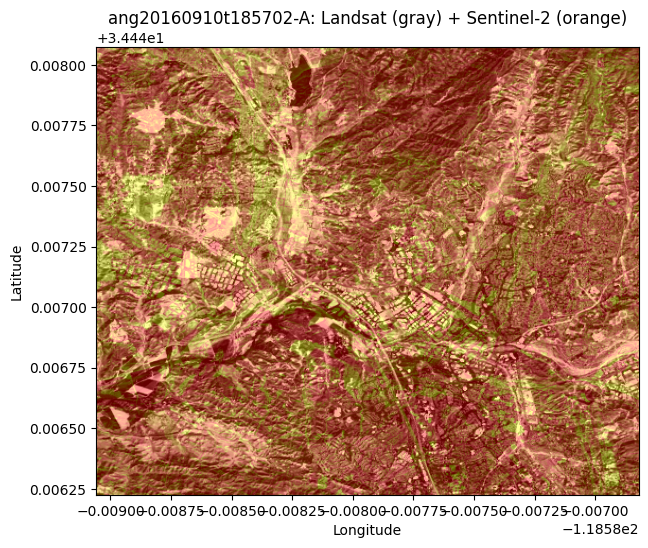

In [3]:
import ast
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tifffile

plume_id = "ang20160910t185702-A"
csv_path = Path("../carbon_mapper_data/csvs/merged_file_with_s2.csv")

# Look up plume bounds once
with csv_path.open() as f:
    for row in csv.DictReader(f):
        if row["plume_id"] == plume_id:
            lon_min, lat_min, lon_max, lat_max = ast.literal_eval(row["plume_bounds"])
            break

extent = [lon_min, lon_max, lat_min, lat_max]

# Pick a Landsat scene and Sentinel-2 stack for this plume
l8 = tifffile.imread(
    "../carbonmapper_data_l89_l2sp/ang20160910t185702-A/"
    "l8_LC08_L2SP_041036_20160910_20200906_02_T1.tif"
)[3]  # e.g., SR_B4

s2 = tifffile.imread(
    "../carbonmapper_data_s2_l2a/ang20160910t185702-A/s2_20160906T182922Z.tif"
)[3]  # e.g., band 4 (red)

plt.figure(figsize=(7, 7))
plt.imshow(l8, extent=extent, origin="upper",
           cmap="gray", vmin=np.percentile(l8, 5), vmax=np.percentile(l8, 95))
plt.imshow(s2, extent=extent, origin="upper",
           cmap="autumn", alpha=0.4,
           vmin=np.percentile(s2, 5), vmax=np.percentile(s2, 95))
plt.title(f"{plume_id}: Landsat (gray) + Sentinel-2 (orange)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


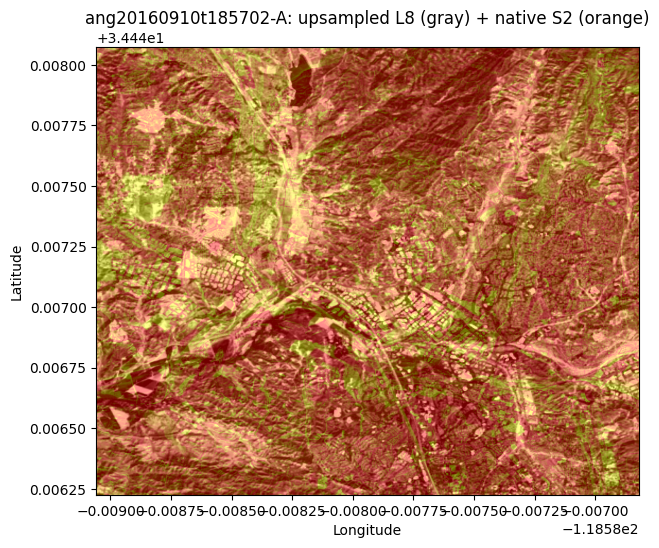

In [11]:
import ast
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tifffile
from scipy.ndimage import zoom  # pip install scipy if missing

plume_id = "ang20160910t185702-A"
csv_path = Path("../carbon_mapper_data/csvs/merged_file_with_s2.csv")

with csv_path.open() as f:
    for row in csv.DictReader(f):
        if row["plume_id"] == plume_id:
            lon_min, lat_min, lon_max, lat_max = ast.literal_eval(row["plume_bounds"])
            break
extent = [lon_min, lon_max, lat_min, lat_max]

l8 = tifffile.imread(
    "../carbonmapper_data_l89_l2sp/ang20160910t185702-A/"
    "l8_LC08_L2SP_041036_20160910_20200906_02_T1.tif"
)[3]
s2 = tifffile.imread(
    "../carbonmapper_data_s2_l2a/ang20160910t185702-A/s2_20160906T182922Z.tif"
)[3]

scale = 30 / 20  # enlarge L8 pixels so they match 20 m spacing
l8_up = zoom(l8, zoom=scale, order=1)  # bilinear interpolation

plt.figure(figsize=(7, 7))
plt.imshow(l8_up, extent=extent, origin="upper",
           cmap="gray", vmin=np.percentile(l8_up, 5), vmax=np.percentile(l8_up, 95))
plt.imshow(s2, extent=extent, origin="upper",
           cmap="autumn", alpha=0.45,
           vmin=np.percentile(s2, 5), vmax=np.percentile(s2, 95))
plt.title(f"{plume_id}: upsampled L8 (gray) + native S2 (orange)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


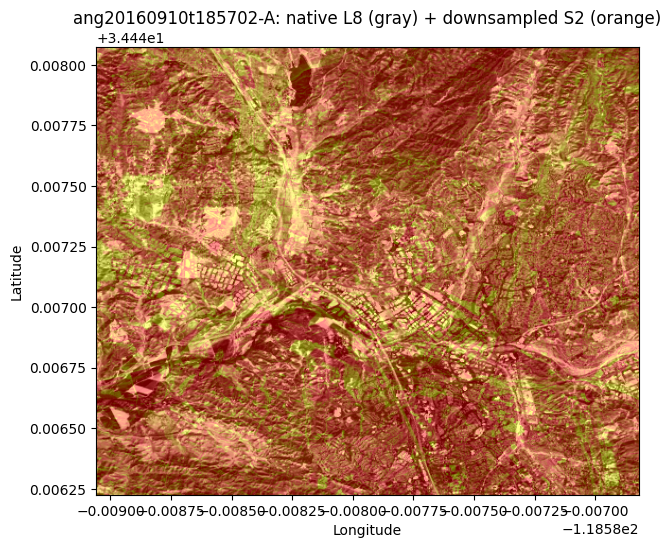

In [16]:
import ast
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tifffile
from skimage.transform import resize  # pip install scikit-image if missing

plume_id = "ang20160910t185702-A"
csv_path = Path("../carbon_mapper_data/csvs/merged_file_with_s2.csv")

with csv_path.open() as f:
    for row in csv.DictReader(f):
        if row["plume_id"] == plume_id:
            lon_min, lat_min, lon_max, lat_max = ast.literal_eval(row["plume_bounds"])
            break
extent = [lon_min, lon_max, lat_min, lat_max]

l8 = tifffile.imread(
    "../carbonmapper_data_l89_l2sp/ang20160910t185702-A/"
    "l8_LC08_L2SP_041036_20160910_20200906_02_T1.tif"
)[3]
s2 = tifffile.imread(
    "../carbonmapper_data_s2_l2a/ang20160910t185702-A/s2_20160906T182922Z.tif"
)[3]

# Resize S2 to L8’s shape using area-weighted averaging (anti_aliasing=True)
s2_down = resize(
    s2,
    output_shape=l8.shape,
    order=1,               # bilinear kernel on the averaged grid
    mode="reflect",
    anti_aliasing=True,    # enforces area averaging during decimation
    preserve_range=True,
).astype(s2.dtype)

plt.figure(figsize=(7, 7))
plt.imshow(l8, extent=extent, origin="upper",
           cmap="gray", vmin=np.percentile(l8, 5), vmax=np.percentile(l8, 95))
plt.imshow(s2_down, extent=extent, origin="upper",
           cmap="autumn", alpha=0.45,
           vmin=np.percentile(s2_down, 5), vmax=np.percentile(s2_down, 95))
plt.title(f"{plume_id}: native L8 (gray) + downsampled S2 (orange)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [3]:
import tifffile as tiff
import numpy as np

tif_path = "../carbonmapper_data_s2_l2a/av320250724t160634-A/s2_20250724T160829Z.tif"

arr = tiff.imread(tif_path)   # shape should be (C, H, W)
print("shape:", arr.shape)    # e.g. (12, 512, 512)

C, H, W = arr.shape
for i in range(C):
    band = arr[i]
    print(
        f"Band {i}: shape={band.shape}, "
        f"min={band.min()}, max={band.max()}, mean={band.mean():.2f}"
    )
tif_path_l8 = "../carbonmapper_data_l89_l2sp/av320250724t160634-A/l8_LC09_L2SP_018033_20250724_20250727_02_T1.tif"

arr_l8 = tiff.imread(tif_path_l8)
print("L8/9 shape:", arr_l8.shape)
C, H, W = arr_l8.shape
for i in range(C):
    band = arr_l8[i]
    print(
        f"L8 Band {i}: shape={band.shape}, "
        f"min={band.min()}, max={band.max()}, mean={band.mean():.2f}"
    )


shape: (12, 512, 512)
Band 0: shape=(512, 512), min=1133, max=5089, mean=1349.39
Band 1: shape=(512, 512), min=1135, max=5356, mean=1363.24
Band 2: shape=(512, 512), min=1131, max=5277, mean=1526.12
Band 3: shape=(512, 512), min=1070, max=5225, mean=1314.57
Band 4: shape=(512, 512), min=1157, max=5703, mean=1828.08
Band 5: shape=(512, 512), min=1177, max=6569, mean=3756.10
Band 6: shape=(512, 512), min=1224, max=7524, mean=4525.07
Band 7: shape=(512, 512), min=1159, max=7740, mean=4805.43
Band 8: shape=(512, 512), min=0, max=0, mean=0.00
Band 9: shape=(512, 512), min=0, max=0, mean=0.00
Band 10: shape=(512, 512), min=1135, max=10142, mean=2964.88
Band 11: shape=(512, 512), min=1080, max=15186, mean=1888.51
L8/9 shape: (8, 512, 512)
L8 Band 0: shape=(512, 512), min=4004, max=18943, mean=7983.47
L8 Band 1: shape=(512, 512), min=5316, max=20513, mean=8013.41
L8 Band 2: shape=(512, 512), min=7661, max=21984, mean=8722.43
L8 Band 3: shape=(512, 512), min=7373, max=23550, mean=8177.28
L8 Ban

In [1]:
import pandas as pd

# Files
s2_path = "../carbon_mapper_data/csvs/merged_file_with_s2_with_mask_flags.csv"
l8_path = "../carbon_mapper_data/csvs/merged_file_with_l8.csv"

# Columns that define the shared Carbon Mapper “core” record
carbon_cols = [
    "plume_id", "plume_latitude", "plume_longitude", "datetime",
    "ipcc_sector", "gas", "emission_cmf_type", "plume_bounds",
    "instrument", "mission_phase", "published_at", "modified",
    "emission_version", "processing_software", "gsd", "sensitivity_mode",
    "off_nadir", "emission_auto", "emission_uncertainty_auto",
    "wind_speed_avg_auto", "wind_speed_std_auto", "wind_direction_avg_auto",
    "wind_direction_std_auto", "wind_source_auto", "platform", "provider",
    "plume_tif", "plume_png", "con_tif", "rgb_tif", "rgb_png",
]

s2_df = pd.read_csv(s2_path)
l8_df = pd.read_csv(l8_path)

# Keep only the Carbon Mapper columns + the unique L8 columns to avoid duplicates
l8_extra_cols = [c for c in l8_df.columns if c not in carbon_cols]
l8_df = l8_df[carbon_cols + l8_extra_cols]

merged_df = pd.merge(s2_df, l8_df, on=carbon_cols, how="left")

# Work with merged_df as needed, e.g., inspect or save:
merged_df.to_csv("../carbon_mapper_data/csvs/merged_file_with_s2_l8.csv", index=False)


/tmp/ipykernel_1249789/499138152.py:19: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  s2_df = pd.read_csv(s2_path)
/tmp/ipykernel_1249789/499138152.py:20: DtypeWarning: Columns (15,31,32,33,40,41,42,49,50,51) have mixed types. Specify dtype option on import or set low_memory=False.
  l8_df = pd.read_csv(l8_path)


In [1]:
import pandas as pd

# Display options — expand columns & rows
pd.set_option("display.max_columns", None)  # show all columns
pd.set_option("display.max_rows", 200)      # adjust if necessary
pd.set_option("display.width", 2000)        # wide console formatting
pd.set_option("display.max_colwidth", None) # don't truncate long strings

path = "/data2/yuyao/methane_emission/carbon_mapper_data/csvs/merged_file_with_s2_90360.csv"
df = pd.read_csv(path, low_memory=False)  # removes dtype warning

print(df.shape)
print(df.dtypes.value_counts())

# Numeric summaries
num_stats = df.describe(include="number")
print(num_stats)

# Categorical summaries (top values, counts, etc.)
cat_stats = df.describe(include="object")
print(cat_stats)

# Optional: missing values
missing_counts = df.isna().sum().sort_values(ascending=False)
print(missing_counts.head(20))


(24470, 41)
object     27
float64    14
Name: count, dtype: int64
       plume_latitude  plume_longitude          gsd    off_nadir  emission_auto  emission_uncertainty_auto  wind_speed_avg_auto  wind_speed_std_auto  wind_direction_avg_auto  wind_direction_std_auto  s2_minus90_height  s2_minus90_width  s2_minus360_height  s2_minus360_width
count    24470.000000     24470.000000  6977.000000  6977.000000   20929.000000               20933.000000         23343.000000         17495.000000             17485.000000             17485.000000       24228.000000      24228.000000        24324.000000       24324.000000
mean        31.411164       -54.803231    36.623196    17.613621     978.509263                 254.721116             3.215690             0.442707               193.244114                15.149431         509.254912        507.462110          509.039796         507.207984
std         15.031242        79.709871     3.284456     9.586590    1615.203762                 374.459540   

In [3]:
#!/usr/bin/env python3
import re
from datetime import datetime
from pathlib import Path

import pandas as pd
import tifffile

CSV_PATH = Path("../carbon_mapper_data/csvs/merged_file_with_s2_90360.csv")
BASE_DIR = Path("/data2/yuyao/methane_emission/carbonmapper_data_l2a_90360")
OFFSETS = (90, 360)
FILENAME_RE = re.compile(r"s2_minus(?P<offset>\d+)_(?P<stamp>\d{8}T\d{6})Z?\.tif$", re.IGNORECASE)

df = pd.read_csv(CSV_PATH)

for offset in OFFSETS:
    for suffix in ("datetime", "tif", "height", "width"):
        col = f"s2_minus{offset}_{suffix}"
        if col not in df.columns:
            df[col] = ""

def infer_hw(path: Path):
    try:
        with tifffile.TiffFile(path) as tif:
            shape = tif.series[0].shape
        if len(shape) == 3:
            _, h, w = shape
        else:
            h, w = shape
        return int(h), int(w)
    except Exception:
        return "", ""

for idx, row in df.iterrows():
    plume_id = str(row.get("plume_id", "")).strip()
    if not plume_id:
        continue
    plume_dir = BASE_DIR / plume_id
    if not plume_dir.is_dir():
        continue

    for tif_path in plume_dir.glob("s2_minus*.tif"):
        match = FILENAME_RE.match(tif_path.name)
        if not match:
            continue
        offset = int(match.group("offset"))
        if offset not in OFFSETS:
            continue
        stamp = match.group("stamp") + "Z"
        iso_dt = datetime.strptime(match.group("stamp"), "%Y%m%dT%H%M%S").strftime("%Y-%m-%dT%H:%M:%SZ")
        height, width = infer_hw(tif_path)
        df.at[idx, f"s2_minus{offset}_datetime"] = iso_dt
        df.at[idx, f"s2_minus{offset}_tif"] = str(tif_path)
        df.at[idx, f"s2_minus{offset}_height"] = height
        df.at[idx, f"s2_minus{offset}_width"] = width

df.to_csv(CSV_PATH, index=False)
print("Refreshed s2_minus columns based on existing TIFFs.")


/tmp/ipykernel_428640/2401249616.py:14: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CSV_PATH)


Refreshed s2_minus columns based on existing TIFFs.


In [3]:
import pandas as pd

# Translated comment
df = pd.read_csv("../carbon_mapper_data/csvs/merged_file_with_s2_l8.csv")  # Translated comment


# Translated comment
# Translated comment
keep_columns = [
    "plume_id",
    "plume_latitude",
    "plume_longitude",
    "datetime",
    "ipcc_sector",
    "plume_bounds",
    "emission_auto",
    "emission_uncertainty_auto",
    "wind_speed_avg_auto",      # later replace to ERA5
    "wind_speed_std_auto",
    "wind_direction_avg_auto",
    "wind_direction_std_auto",
    "plume_tif",
    "con_tif",
    "s2_1_datetime",
    "s2_1_path",
    "s2_2_datetime",
    "s2_2_path",
    "s2_3_datetime",
    "s2_3_path",
    "has_same_day_s2 (±24h)",
    "l8_1_scene_id",
    "l8_1_datetime",
    "l8_1_tif",
    "l8_1_sun_azimuth",
    "l8_1_sun_elevation",
    "l8_2_scene_id",
    "l8_2_datetime",
    "l8_2_tif",
    "l8_2_sun_azimuth",
    "l8_2_sun_elevation",
    "l8_3_scene_id",
    "l8_3_datetime",
    "l8_3_tif",
    "l8_3_sun_azimuth",
    "l8_3_sun_elevation",
]

# Translated comment
keep_columns = [c for c in keep_columns if c in df.columns]


# Translated comment
df_filtered = df[keep_columns]


# Translated comment
df_filtered.to_csv("../carbon_mapper_data/csvs/merged_file_with_s2_l8_filtered.csv", index=False)  # Translated comment

print("Done! :", len(keep_columns))


In [3]:
import pandas as pd
from datetime import datetime, timedelta

# Translated comment
csv_path = "../carbon_mapper_data/csvs/merged_file_with_s2_l8_filtered_with_flags_low_cloud_only.csv"
# Translated comment

df = pd.read_csv(csv_path, low_memory=False)

window = timedelta(hours=24)

def flag_within_window(row, cols):
    """
 DictReader :  - plume_dt fromisoformat + replace("Z", "+00:00")
 - col , +/-24h 1
 - 0
    """
    # Translated comment
    base_raw = str(row["datetime"])
    try:
        plume_dt = datetime.fromisoformat(base_raw.replace("Z", "+00:00"))
    except Exception:
        return 0

    for col in cols:
        if col not in row:
            continue
        v = row[col]

        # Translated comment
        if pd.isna(v):
            continue
        v_str = str(v).strip()
        if not v_str:
            continue

        try:
            s2_dt = datetime.fromisoformat(v_str.replace("Z", "+00:00"))
        except Exception:
            # Translated comment
            continue

        if abs(s2_dt - plume_dt) <= window:
            return 1

    return 0


# Translated comment
s2_cols = ["s2_1_datetime", "s2_2_datetime", "s2_3_datetime"]
l8_cols = ["l8_1_datetime", "l8_2_datetime", "l8_3_datetime"]

# Translated comment
df["has_same_day_s2 (±24h)"] = df.apply(lambda r: flag_within_window(r, s2_cols), axis=1)
df["has_same_day_l8 (±24h)"] = df.apply(lambda r: flag_within_window(r, l8_cols), axis=1)

# Translated comment
df["has_same_day_s2_l8 (±24h)"] = (
    (df["has_same_day_s2 (±24h)"] == 1) &
    (df["has_same_day_l8 (±24h)"] == 1)
).astype(int)

# save
# df.to_csv(out_path, index=False)

print("Done!")
print("S2 within ±24h :", int(df["has_same_day_s2 (±24h)"].sum()))
print("L8 within ±24h :", int(df["has_same_day_l8 (±24h)"].sum()))
print("Both S2 & L8   :", int(df["has_same_day_s2_l8 (±24h)"].sum()))


Done!
S2 within ±24h : 3710
L8 within ±24h : 2573
Both S2 & L8   : 568


In [10]:
import pandas as pd
from datetime import datetime, timedelta

# Translated comment
csv_path = "../carbon_mapper_data/csvs/merged_file_with_s2_l8_filtered_with_flags_low_cloud_only.csv"

df = pd.read_csv(csv_path, low_memory=False)
print(len(df))
window = timedelta(hours=168)

def flag_within_window(row, cols):
    """
 DictReader :  - plume_dt fromisoformat + replace("Z", "+00:00")
 - col , +/-24h 1
 - 0
    """
    # Translated comment
    base_raw = str(row["datetime"])
    try:
        plume_dt = datetime.fromisoformat(base_raw.replace("Z", "+00:00"))
    except Exception:
        return 0

    for col in cols:
        if col not in row:
            continue
        v = row[col]

        # Translated comment
        if pd.isna(v):
            continue
        v_str = str(v).strip()
        if not v_str:
            continue

        try:
            s2_dt = datetime.fromisoformat(v_str.replace("Z", "+00:00"))
        except Exception:
            # Translated comment
            continue

        # if s2_dt - plume_dt <= window:
        if s2_dt - plume_dt <= window or plume_dt - s2_dt <= window:
            return 1

    return 0


# Translated comment
s2_cols = ["s2_1_datetime", "s2_2_datetime", "s2_3_datetime"]
l8_cols = ["l8_1_datetime", "l8_2_datetime", "l8_3_datetime"]

# Translated comment
df["has_same_day_s2 (+24h)"] = df.apply(lambda r: flag_within_window(r, s2_cols), axis=1)
df["has_same_day_l8 (+24h)"] = df.apply(lambda r: flag_within_window(r, l8_cols), axis=1)

# Translated comment
df["has_same_day_s2_l8 (+24h)"] = (
    (df["has_same_day_s2 (+24h)"] == 1) &
    (df["has_same_day_l8 (+24h)"] == 1)
).astype(int)

print("Done!")
print("S2 within ±24h :", int(df["has_same_day_s2 (+24h)"].sum()))
print("L8 within ±24h :", int(df["has_same_day_l8 (+24h)"].sum()))
print("Both S2 & L8   :", int(df["has_same_day_s2_l8 (+24h)"].sum()))

15681
Done!
S2 within ±24h : 9855
L8 within ±24h : 11493
Both S2 & L8   : 5667


In [2]:
import pandas as pd
from pathlib import Path
import xml.etree.ElementTree as ET
from functools import lru_cache

CSV_PATH = Path("../carbon_mapper_data/csvs/merged_file_with_s2_l8_filtered_with_flags.csv")
S2_ROOT = Path("../data/raw_data_dir_S2")
L8_ROOT = Path("../data/raw_data_dir_L89_L2SP")

df = pd.read_csv(CSV_PATH)


@lru_cache(maxsize=None)
def _read_s2_cloud(meta_path_str: str):
    meta_path = Path(meta_path_str)
    try:
        value = ET.parse(meta_path).findtext(".//Cloud_Coverage_Assessment")
        return float(value) if value else None
    except Exception:
        return None


def _normalize_safe_names(raw_value) -> list[str]:
    if pd.isna(raw_value):
        return []
    text = str(raw_value).strip()
    if not text:
        return []
    name = Path(text).name.replace(".SAFE.zip", ".SAFE")
    candidates = []
    if name.endswith(".SAFE"):
        candidates.append(name)
        candidates.append(name[:-5])
    else:
        candidates.append(name)
        candidates.append(f"{name}.SAFE")
    return [c for c in candidates if c]


def fetch_s2_cloud(raw_path):
    if pd.isna(raw_path):
        return None
    text = str(raw_path).strip()
    if not text:
        return None
    path = Path(text)
    if path.suffix == ".zip":
        path = Path(text[:-4])
    candidate_dirs = []
    if path.exists():
        candidate_dirs.append(path)
    for name in _normalize_safe_names(text):
        candidate_dirs.append(S2_ROOT / name)
    for directory in candidate_dirs:
        meta = directory / "MTD_MSIL2A.xml"
        if meta.exists():
            return _read_s2_cloud(meta.as_posix())
    return None


@lru_cache(maxsize=None)
def _read_l8_cloud(scene_id: str):
    folder = L8_ROOT / scene_id
    meta = folder / f"{scene_id}_MTL.txt"
    if not meta.exists():
        return None
    for line in meta.read_text().splitlines():
        if "CLOUD_COVER =" in line:
            try:
                return float(line.split("=")[1])
            except ValueError:
                return None
    return None


def fetch_l8_cloud(scene_id):
    if pd.isna(scene_id):
        return None
    scene_id = str(scene_id).strip()
    return _read_l8_cloud(scene_id) if scene_id else None


for i in range(1, 4):
    df[f"s2_{i}_cloud_cover"] = df[f"s2_{i}_path"].apply(fetch_s2_cloud)
    df[f"l8_{i}_cloud_cover"] = df[f"l8_{i}_scene_id"].apply(fetch_l8_cloud)

df.to_csv(CSV_PATH, index=False)
print("Cloud cover columns added ✔")


/tmp/ipykernel_4000791/2741907210.py:10: DtypeWarning: Columns (20,21,22,25,26,27,30,31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CSV_PATH)


Cloud cover columns added ✔


In [5]:
import pandas as pd
from pathlib import Path

CSV_PATH = Path("../carbon_mapper_data/csvs/merged_file_with_s2_l8_filtered_with_flags.csv")

df = pd.read_csv(CSV_PATH, low_memory=False)
cloud_cols = [col for col in df.columns if col.endswith("_cloud_cover")]

print("cloud_cover < 20% counts:")
for col in cloud_cols:
    series = pd.to_numeric(df[col], errors="coerce")
    count = int((series < 20).fillna(False).sum())
    total = int(series.notna().sum())
    print(f"{col}: {count} / {total}")


cloud_cover < 20% counts:
s2_1_cloud_cover: 8160 / 11809
l8_1_cloud_cover: 9462 / 15219
s2_2_cloud_cover: 6387 / 8885
l8_2_cloud_cover: 5758 / 9538
s2_3_cloud_cover: 4089 / 5930
l8_3_cloud_cover: 2433 / 4169


In [15]:
import pandas as pd
CSV_PATH = "../carbon_mapper_data/csvs/merged_file_with_s2_l8_filtered_with_flags_low_cloud_only.csv"
df = pd.read_csv(CSV_PATH, low_memory=False)
print(len(df))
df = df[(df['s2_1_cloud_cover'].notnull() | df['s2_2_cloud_cover'].notnull() | df['s2_3_cloud_cover'].notnull()) & (df['l8_1_cloud_cover'].notnull()| df['l8_2_cloud_cover'].notnull() | df['l8_3_cloud_cover'].notnull())]
# df = df[(df['s2_1_cloud_cover'].notnull() | df['s2_2_cloud_cover'].notnull() | df['s2_3_cloud_cover'].notnull())]
# df = df[(df['l8_1_cloud_cover'].notnull()| df['l8_2_cloud_cover'].notnull() | df['l8_3_cloud_cover'].notnull())]
print(len(df))

15681
5667


/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/tmp/ipykernel_3661486/3604973883.py:123: UserWarning: Glyph 32972 (\N{CJK UNIFIED IDEOGRAPH-80CC}) missing from font(s) DejaVu Sans.
  fig.savefig(save_png, bbox_inches="tight", dpi=200)
/tmp/ipykernel_3661486/3604973883.py:123: UserWarning: Glyph 26223 (\N{CJK UNIFIED IDEOGRAPH-666F}) missing from font(s) DejaVu Sans.
  fig.savefig(save_png, bbox_inches="tight", dpi=200)
/tmp/ipykernel_3661486/3604973883.py:123: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  fig.savefig(save_png, bbox_inches="tight", dpi=200)
/tmp/ipykernel_3661486/3604973883.py:123: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  fig.savefig(save_png, bbox_inch

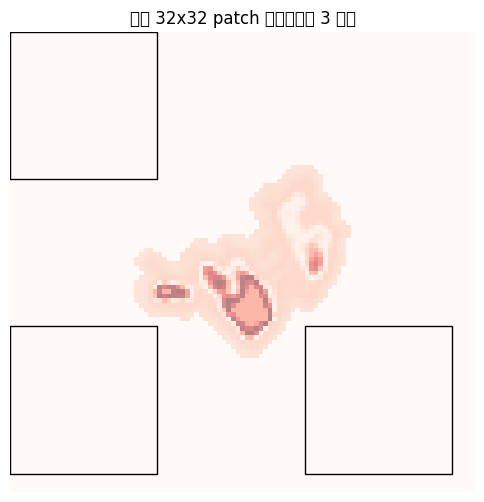

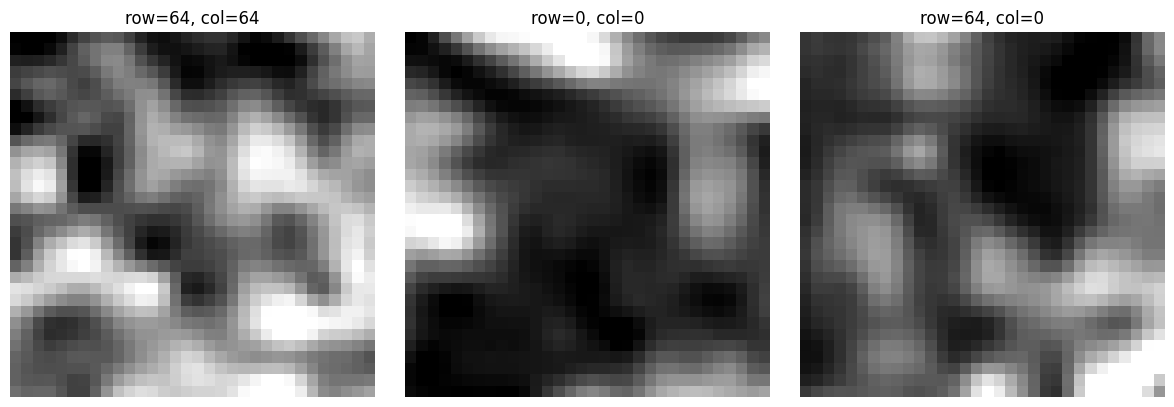

In [ ]:
import rasterio as rio
from rasterio.windows import Window
import matplotlib.pyplot as plt
import numpy as np
from rasterio.plot import show
from matplotlib.patches import Rectangle


def find_background_windows(plume_tif, chip=32, stride=64, max_windows=None):
    """
 plume mask 0 32x32 .

     ----
    plume_tif : str
 plume mask path( S2 )
    chip : int
 patch ( 224)
    stride : int
 : , ; ,  max_windows : int None
 coordinates(None )

     ----
    windows : list[(row_off, col_off)]
     """
    with rio.open(plume_tif) as plume_ds:
        mask = plume_ds.read(1)
        H, W = mask.shape

        windows = []
        for row in range(0, H - chip + 1, stride):
            for col in range(0, W - chip + 1, stride):
                patch = mask[row:row + chip, col:col + chip]
                # Translated comment
                if np.all(patch == 0):
                    windows.append((row, col))
                    if max_windows is not None and len(windows) >= max_windows:
                        return windows

    return windows
def show_background_patches(plume_tif, aligned_s2_tif,
                            chip=32, stride=64,
                            num_samples=4, save_png=None):
    """
 figure plume + patch ,  num_samples 224x224 patch content.
    """
    # Translated comment
    windows = find_background_windows(plume_tif, chip=chip, stride=stride)
 print(f" {chip}x{chip} : {len(windows)}")

    if len(windows) == 0:
 print("⚠️ 224x224 ")
        return

    # Translated comment
    rng = np.random.default_rng(42)
    idx = rng.choice(len(windows),
                     size=min(num_samples, len(windows)),
                     replace=False)
    sampled_windows = [windows[i] for i in idx]

    with rio.open(aligned_s2_tif) as s2_ds, rio.open(plume_tif) as plume_ds:
        # Translated comment
        fig, ax = plt.subplots(1, 1, figsize=(6, 6))

        # Translated comment
        if s2_ds.count >= 3:
            bands = [1, 2, 3]
            rgb = s2_ds.read(bands).astype("float32")

            for i in range(rgb.shape[0]):
                band = rgb[i]
                valid = band > 0
                if not np.any(valid):
                    continue
                p2, p98 = np.percentile(band[valid], (40, 60))
                if p98 > p2:
                    band = (band - p2) / (p98 - p2)
                else:
                    band = band * 0.0
                rgb[i] = np.clip(band, 0, 1)

            show(rgb, transform=s2_ds.transform, ax=ax, adjust='linear')
        else:
            band1 = s2_ds.read(1).astype("float32")
            valid = band1 > 0
            if np.any(valid):
                p2, p98 = np.percentile(band1[valid], (2, 98))
                if p98 > p2:
                    band1 = (band1 - p2) / (p98 - p2)
            band1 = np.clip(band1, 0, 1)
            show(band1, transform=s2_ds.transform, ax=ax, cmap="gray")

        # Translated comment
        show(plume_ds.read(1),
             transform=plume_ds.transform,
             ax=ax, alpha=0.5, cmap="Reds")

        # Translated comment
        transform = plume_ds.transform
        for (row, col) in sampled_windows:
            # Translated comment
            x0, y0 = rio.transform.xy(transform, row, col, offset='ul')
            # Translated comment
            px_w = transform.a
            px_h = -transform.e  # Translated comment
            rect = Rectangle(
                (x0, y0 - chip * px_h),
                chip * px_w,
                chip * px_h,
                fill=False,
                linewidth=1.0
            )
            ax.add_patch(rect)

 ax.set_title(f" {chip}x{chip} patch location( {len(sampled_windows)} )")
        ax.set_axis_off()
        if save_png:
            fig.savefig(save_png, bbox_inches="tight", dpi=200)

        plt.show()

        # Translated comment
        fig2, axes = plt.subplots(1, len(sampled_windows),
                                  figsize=(4 * len(sampled_windows), 4))
        if len(sampled_windows) == 1:
            axes = [axes]

        for ax_i, (row, col) in zip(axes, sampled_windows):
            window = Window(col_off=col, row_off=row,
                            width=chip, height=chip)
            # Translated comment
            if s2_ds.count >= 3:
                patch_rgb = s2_ds.read(bands, window=window).astype("float32")
                # Translated comment
                for i in range(patch_rgb.shape[0]):
                    band = patch_rgb[i]
                    valid = band > 0
                    if not np.any(valid):
                        continue
                    p2, p98 = np.percentile(band[valid], (2, 98))
                    if p98 > p2:
                        band = (band - p2) / (p98 - p2)
                    else:
                        band = band * 0.0
                    patch_rgb[i] = np.clip(band, 0, 1)
                patch_rgb = np.transpose(patch_rgb, (1, 2, 0))  # (H, W, C)
                ax_i.imshow(patch_rgb)
            else:
                patch_band1 = s2_ds.read(1, window=window).astype("float32")
                valid = patch_band1 > 0
                if np.any(valid):
                    p2, p98 = np.percentile(patch_band1[valid], (2, 98))
                    if p98 > p2:
                        patch_band1 = (patch_band1 - p2) / (p98 - p2)
                patch_band1 = np.clip(patch_band1, 0, 1)
                ax_i.imshow(patch_band1, cmap="gray")

            ax_i.set_title(f"row={row}, col={col}")
            ax_i.axis("off")

        plt.tight_layout()
        plt.show()
plume_path = "/data2/yuyao/methane_emission/CM_S2_l8/ang20160910t185702-A/plume.tif"
aligned_s2_path = "../CM_S2_l8/ang20160910t185702-A/s2_20160906T182922Z.tif"

show_background_patches(
    plume_path,
    aligned_s2_path,
    chip=32,
    stride=64,  # Translated comment
    num_samples=4,
    save_png="./ang20160910t185702-A_bg_patches.png",
)


In [ ]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data_csv")
CSV_NAMES = ["CM_s2_l8_s2.csv", "CM_s2_l8_l89.csv"]

def chronological_split(df: pd.DataFrame, frac: float = 0.9):
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["image_timestamp"])
    df["site_id"] = (
        df["plume_latitude"].round(5).astype(str)
        + "_"
        + df["plume_longitude"].round(5).astype(str)
    )

    site_stats = (
        df.groupby("site_id")
          .agg(last_time=("timestamp", "max"), sample_count=("timestamp", "size"))
          .sort_values("last_time")
    )

    cutoff = frac * site_stats["sample_count"].sum()
    running = 0
    train_sites = []
    for site, row in site_stats.iterrows():
        if running < cutoff:
            train_sites.append(site)
            running += row["sample_count"]
        else:
            break

    train_mask = df["site_id"].isin(train_sites)
    train_df = df[train_mask].sort_values("timestamp").drop(columns=["timestamp", "site_id"])
    test_df = df[~train_mask].sort_values("timestamp").drop(columns=["timestamp", "site_id"])
    return train_df, test_df

for csv_name in CSV_NAMES:
    df = pd.read_csv(DATA_DIR / csv_name)
    train_df, test_df = chronological_split(df, frac=0.9)

    train_path = DATA_DIR / csv_name.replace(".csv", "_train.csv")
    test_path = DATA_DIR / csv_name.replace(".csv", "_test.csv")
    train_df.to_csv(train_path, index=False)
    test_df.to_csv(test_path, index=False)

    print(f"{csv_name}: train={len(train_df)} rows, test={len(test_df)} rows "
          f"({train_df['image_path'].iloc[0]} oldest → {test_df['image_path'].iloc[-1]} latest)")

CM_s2_l8_s2.csv: train=43314 rows, test=4812 rows (CM_s2_l8_s2/ang20160917t181611-A/s2_20160916T184422Z/fg_03/image.tif oldest → CM_s2_l8_s2/tan20251024t061109c86s4001-K/s2_20251025T052921Z/bg_03/image.tif latest)
CM_s2_l8_l89.csv: train=29958 rows, test=3324 rows (CM_s2_l8_l89/ang20160910t185702-A/l89_LC08_L2SP_041036_20160910_20200906_02_T1_20160910T182833Z/fg_01/image.tif oldest → CM_s2_l8_l89/av320250917t184127-A/l89_LC08_L2SP_043034_20250917_20250929_02_T1_20250917T184006Z/bg_03/image.tif latest)


In [3]:
from pathlib import Path

root = Path("/data2/yuyao/methane_emission/carbon_mapper_data/CM_S2_L2A")
count = sum(1 for _ in root.rglob("s2.tif"))
print(count)

4358


In [5]:
from pathlib import Path
import re

root = Path("/data2/yuyao/methane_emission/carbonmapper_data_s2_l2a_gee_download")
pattern = re.compile(r"^(?P<plume>.+?)_(?P<kind>reference_month|reference_year|leak_[0-3])\.tif$")

has_month = set()
has_year = set()
has_leak = set()
all_plumes = set()

for f in root.glob("*.tif"):
    m = pattern.match(f.name)
    if not m:
        continue
    plume = m.group("plume")
    kind = m.group("kind")
    all_plumes.add(plume)
    if kind == "reference_month":
        has_month.add(plume)
    elif kind == "reference_year":
        has_year.add(plume)
    elif kind.startswith("leak_"):
        has_leak.add(plume)

count_month = len(has_month)
count_year = len(has_year)
count_leak = len(has_leak)
count_all_three = len(has_month & has_year & has_leak)
count_month_year = len((has_month & has_year) - has_leak)

print("month:", count_month)
print("year:", count_year)
print("leak:", count_leak)
print("month+year+leak:", count_all_three)
print("month+year only:", count_month_year)


month: 23844
year: 23844
leak: 13166
month+year+leak: 13166
month+year only: 10678


In [ ]:
from pathlib import Path
import statistics as stats
import xarray as xr

root = Path("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/data_download/raw_data_dir_s5p")

sizes = []  # (H, W)

for nc in root.rglob("*.nc"):
    try:
        with xr.open_dataset(nc) as ds:
            var = None
            for name, da in ds.data_vars.items():
                if da.ndim == 2:
                    var = da
                    break
            if var is not None:
                h, w = var.shape
                sizes.append((h, w))
    except Exception as e:
        print(f"skip bad nc: {nc} | {type(e).__name__}: {e}")

print("total nc files:", len(list(root.rglob('*.nc'))))
if sizes:
    areas = [h * w for h, w in sizes]
    print("min size (HxW):", sizes[areas.index(min(areas))])
    print("max size (HxW):", sizes[areas.index(max(areas))])
    print("mean area:", stats.mean(areas))
    print("median area:", stats.median(areas))
else:
    print("no 2D variables found")

In [ ]:
from pathlib import Path
import statistics as stats
import xarray as xr

root = Path("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/data_download/raw_data_dir_s5p_90360")

sizes = []  # (H, W)

for nc in root.rglob("*.nc"):
    try:
        with xr.open_dataset(nc) as ds:
            var = None
            for name, da in ds.data_vars.items():
                if da.ndim == 2:
                    var = da
                    break
            if var is not None:
                h, w = var.shape
                sizes.append((h, w))
    except Exception as e:
        print(f"skip bad nc: {nc} | {type(e).__name__}: {e}")

print("total nc files:", len(list(root.rglob('*.nc'))))
if sizes:
    areas = [h * w for h, w in sizes]
    print("min size (HxW):", sizes[areas.index(min(areas))])
    print("max size (HxW):", sizes[areas.index(max(areas))])
    print("mean area:", stats.mean(areas))
    print("median area:", stats.median(areas))
else:
    print("no 2D variables found")

In [1]:
from pathlib import Path
import statistics as stats
import xarray as xr

root = Path("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/data_download/raw_data_dir_s5p")

sizes = []

for nc in root.rglob("*.nc"):
    try:
        with xr.open_dataset(nc, group="PRODUCT") as ds:
            # Translated comment
            if "methane_mixing_ratio" in ds:
                da = ds["methane_mixing_ratio"]
            else:
                da = next(
                    (v for v in ds.data_vars.values() if v.ndim >= 2),
                    None
                )
            if da is not None:
                h, w = da.shape[-2], da.shape[-1]
                sizes.append((h, w))
    except Exception as e:
        print(f"skip bad nc: {nc} | {type(e).__name__}: {e}")

print("total nc files:", len(list(root.rglob("*.nc"))))
if sizes:
    areas = [h * w for h, w in sizes]
    print("min size (HxW):", sizes[areas.index(min(areas))])
    print("max size (HxW):", sizes[areas.index(max(areas))])
    print("mean area:", stats.mean(areas))
    print("median area:", stats.median(areas))
else:
    print("no variables found")

/tmp/ipykernel_273748/1436666402.py:11: FutureWarning: In a future version, xarray will not decode the variable 'delta_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  with xr.open_dataset(nc, group="PRODUCT") as ds:
/tmp/ipykernel_273748/1436666402.py:11: FutureWarning: In a future version, xarray will not decode the variable 'delta_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timed

skip bad nc: /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/data_download/raw_data_dir_s5p/S5P_OFFL_L2__CH4____20240418T073009_20240418T091139_33751_03_020600_20240421T050000.nc | OSError: [Errno -101] NetCDF: HDF error: '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/data_download/raw_data_dir_s5p/S5P_OFFL_L2__CH4____20240418T073009_20240418T091139_33751_03_020600_20240421T050000.nc'


/tmp/ipykernel_273748/1436666402.py:11: FutureWarning: In a future version, xarray will not decode the variable 'delta_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  with xr.open_dataset(nc, group="PRODUCT") as ds:
/tmp/ipykernel_273748/1436666402.py:11: FutureWarning: In a future version, xarray will not decode the variable 'delta_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timed

skip bad nc: /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/data_download/raw_data_dir_s5p/S5P_OFFL_L2__CH4____20250509T115930_20250509T134100_39230_03_020800_20250511T070210.nc | OSError: [Errno -101] NetCDF: HDF error: '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/data_download/raw_data_dir_s5p/S5P_OFFL_L2__CH4____20250509T115930_20250509T134100_39230_03_020800_20250511T070210.nc'


/tmp/ipykernel_273748/1436666402.py:11: FutureWarning: In a future version, xarray will not decode the variable 'delta_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  with xr.open_dataset(nc, group="PRODUCT") as ds:
/tmp/ipykernel_273748/1436666402.py:11: FutureWarning: In a future version, xarray will not decode the variable 'delta_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timed

skip bad nc: /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/data_download/raw_data_dir_s5p/S5P_OFFL_L2__CH4____20250507T105550_20250507T123721_39201_03_020800_20250510T075128.nc | OSError: [Errno -101] NetCDF: HDF error: '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/data_download/raw_data_dir_s5p/S5P_OFFL_L2__CH4____20250507T105550_20250507T123721_39201_03_020800_20250510T075128.nc'


/tmp/ipykernel_273748/1436666402.py:11: FutureWarning: In a future version, xarray will not decode the variable 'delta_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  with xr.open_dataset(nc, group="PRODUCT") as ds:


skip bad nc: /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/data_download/raw_data_dir_s5p/S5P_OFFL_L2__CH4____20250507T160021_20250507T174151_39204_03_020800_20250510T104641.nc | OSError: [Errno -101] NetCDF: HDF error: '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/data_download/raw_data_dir_s5p/S5P_OFFL_L2__CH4____20250507T160021_20250507T174151_39204_03_020800_20250510T104641.nc'
total nc files: 3995
min size (HxW): (2418, 215)
max size (HxW): (4174, 215)
mean area: 887605.2242545728
median area: 896980
